## Level 1: Scientific Problem Framing and Python Foundation
    
**Course:** ICS 2207 Scientific Computing 

**Project:** HydroSense-Kenya  

**Main Goal:** Translate a real irrigation problem into a computational problem using Python.

**Topic:** Scientific computing foundations, Computational thinking, Variables, Reproducibility

**Prepared For:** Dr. Lawrence Nderu

## Appreciating the Background
According to a report dated December, 2022 by the Farm To Market Alliance(FtMA), Kenya, the agricultural sector plays a crucial role in Kenya's economy accounting for 20% of the Gross Domestic Product(GDP)-2022. The sector employs over 40% of the total population and more than 70% of the rural population. Kenya has about 28 million hectares of agricultural land which is approximately 48% of its total land area. Agriculture accounts for 65% of export earnings, and provides 80% of the population with a livelihood. Thus agriculture is a major part of Kenya and any improvements towards it should be considered nationally beneficial.

There are 7.5 million smallholders farmers in Kenya who farm in land sizes between 1-5 arces, accounting for 80% of the country's total agricultural output. These farmers majorly depend on "rained farming systems." This, for context means they only cultivate land according to predetermined farming periods thereby exposing them to drought and unpredictable weather patterns caused by climate change.

**Water Security** or rather, lack thereof is a predominant trait among African countries. In Kenya, farmers and more specifically the smallholder farmers tend to find themselves unable to cultivate the land simply because of lack of water. A study done by 

## Specifying Specific Problem
The terms **water wastage** and **crop moisture stress** in terms of agriculture in Kenya are problems that may be attributed to two main scenarios: Over Irrigarion and Under Irrigation. 

Over Irrigation refers to the application of more water to soil and crops than plants can absorb or the soil can hold, exceeding the actual water requirements. It is a typical mistake made by farmers, especially when soil moisture monitoring instruments are not available. The extra excessive water you applied with the assumption it would help the plant grow even bigger, may be the cause of the plants' wilting and yellow leaves. While the extreme opposite - Under Irrigation is just as much danger to the development of the plant. Under Irrigation refers to supplying insufficient water to meet plant transpiration needs, often caused by water scarcity, poor equipment design, or deliberate action.

Although there are some pointers to when a plant may be getting excessively high or low amounts of water, they are not always caught on time to allow the farmers remedy the situation. Due to this reccurent problem, there is a need for a computerised system to aid smallholder farmers mitigate losses.

## Concequences Arising
There are two major concequences to unreliable irrigation management, namely: **crop stress** and eventually **loss of yields**.

Inadequate soil moisture as a result of either lack of irrigation or improper timing leads to drought stress. This directly reduces photosynthesis, limits growth, and can result in significant yield declines due to pest outbreaks, diseases, and water depletion.

## System Specifications
The system is meant to estimate soil-water balance, detects water stress, simulate uncertainty, and recommends irrigation decisions. All this should be possible given the necessary data which includes: daily weather records, soil-moisture sensor readings, tank-level measurements, pump-flow data and crop-zone parameters.

This system fills the gap of timely detection of the problem that is not achieved by the current system of observation.

## Basic Plot
This will show the trend of rainfall against time in a simple plot.

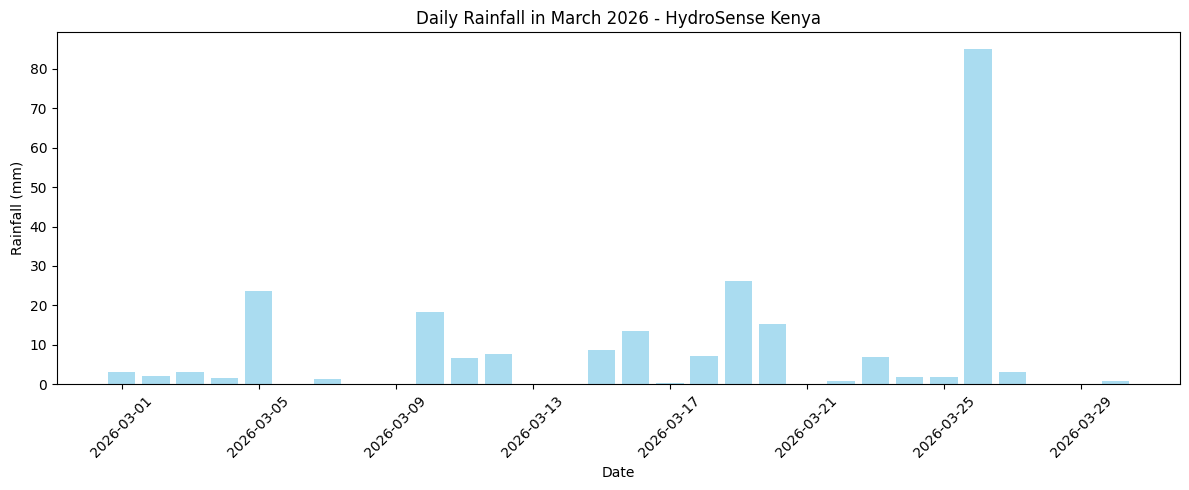

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Loading cleaned data 
project_root = os.path.dirname(os.getcwd())  
processed_path = os.path.join(project_root, "data", "processed", "cleaned_irrigation_dataset.csv")

# Filter only weather data
df = pd.read_csv(processed_path)
weather_data = df[df['dataset_source'] == 'weather'].copy()

# Convert date column
weather_data['date'] = pd.to_datetime(weather_data['date'])

# Create plot
plt.figure(figsize=(12, 5))
plt.bar(weather_data['date'], weather_data['rainfall_mm'], color='skyblue', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.title('Daily Rainfall in March 2026 - HydroSense Kenya')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rainfall_plot.png', dpi=150)
plt.show()

## Assumptions and Limitations of the Initial Model

### Assumptions:
1. **Homogeneous soil**: Soil properties are uniform within each zone
2. **No groundwater contribution**: Water balance ignores capillary rise from water table
3. **Perfect mixing**: Rainfall and irrigation water instantly mix with existing soil water
4. **Linear drainage**: Drainage is proportional to current soil moisture
5. **ET formula simplification**: The empirical ET formula approximates complex crop transpiration processes
6. **Daily timestep**: All processes occur at daily resolution (no sub-daily variations)

### Limitations:
1. **No spatial variability**: Does not account for moisture distribution differences within a zone
2. **No crop growth stage**: ET demand assumed constant; real crops vary by growth phase
3. **No runoff**: Heavy rainfall events may cause surface runoff not captured
4. **No salinity effects**: Water quality and salt accumulation ignored
5. **Sensor accuracy**: Depends on reliable sensor readings; anomalies may affect results
6. **Weather forecast uncertainty**: Future rainfall is unknown (handled later via Monte Carlo)

### Future Improvements:
- Numerical methods for precise irrigation amount 
- Monte Carlo simulation for rainfall uncertainty 
- Optimization for water conservation 
- Runge-Kutta for continuous moisture tracking 

## Testing of the reusable functions
The following functions were written to calculate the water balance and evapotranspiration.

In [3]:
import sys
import os

# Add parent directory to path
sys.path.append(os.path.dirname(os.getcwd()))

from src.numerical_methods import calculate_et, water_balance

print(f"ET sample: {calculate_et(25, 2, 0.7, 60):.2f} mm")
print(f"Water balance sample: {water_balance(30, 10, 0, 4, 0.15):.2f} %")

Testing ET function:
ET at 25°C, 2m/s wind, 0.7 solar, 60% humidity: 3.88 mm

Testing Water Balance function:
Starting at 30%, after rain + ET - drainage: 31.50%
ET sample: 3.88 mm
Water balance sample: 31.50 %
